### chair의 이미지 해상도 통일하여 적용하기

In [1]:
from PIL import Image
import numpy as np

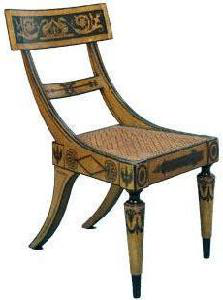

In [4]:
# chair의 1번 이미지
img = Image.open("../Data/chair/image_0001.jpg")
img

In [ ]:
# 배열 크기 확인
np.array(img).shape

(300, 223, 3)

In [6]:
# chair의 2번 이미지
img = Image.open("../Data/chair/image_0002.jpg")
np.array(img).shape

(300, 200, 3)

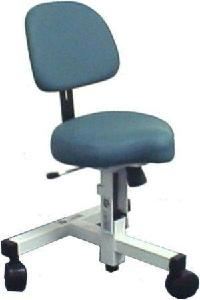

In [7]:
img

> Image의 해상도가 일정하지 않다  
전체 이미지 해상도의 평균값을 가지고 적용

### 전체 이미지 평균 해상도 구하기

In [8]:
import glob

In [13]:
widthRatio = []
heightRatio = []

for file in sorted(glob.glob('../Data/chair/*.jpg')):
    img = np.array(Image.open(file), dtype = np.int32)
    widthRatio.append(img.shape[1])
    heightRatio.append(img.shape[0])

for file in sorted(glob.glob('../Data/laptop/*.jpg')):
    img = np.array(Image.open(file), dtype = np.int32)
    widthRatio.append(img.shape[1])
    heightRatio.append(img.shape[0])

In [14]:
print('chair의 너비 평균 해상도 :', np.mean(widthRatio))
print('chair의 너비 평균 해상도 :', np.mean(heightRatio))

chair의 너비 평균 해상도 : 262.34166666666664
chair의 너비 평균 해상도 : 282.2083333333333


> 너비 : 264, 높이 : 284 로 정함

---
#### chair 이미지 해상도 및 흑백 이미지 변경

In [ ]:
i = 1
for file in sorted(glob.glob('../Data/chair/*.jpg')):
    img = Image.open(file)
    imgResize = img.resize((264, 284), Image.Resampling.LANCZOS)
    imgResize = imgResize.convert('L')
    imgResize.save(f'../Data/chairNew/image_{i:02}.jpg', "JPEG") # f-string 문법. i:02 -> 십의자리 까지 지정한다
    i += 1

#### Laptop 이미지 해상도 및 흑백 이미지 변경

In [16]:
i = 1
for file in sorted(glob.glob('../Data/laptop/*.jpg')):
    img = Image.open(file)
    imgResize = img.resize((264, 284), Image.Resampling.LANCZOS)
    imgResize = imgResize.convert('L')
    imgResize.save(f'../Data/laptopNew/image_{i:02}.jpg', "JPEG") # f-string 문법. i:02 -> 십의자리 까지 지정한다
    i += 1

---
#### chiar image를 Numpy로 변경하기

In [17]:
number_of_data = 60
img_width_size = 264
img_height_size = 284

In [19]:
chairData = np.zeros(
    number_of_data * img_width_size * img_height_size,
    dtype = np.int32
).reshape(
    number_of_data,
    img_height_size,
    img_width_size
)
chairData.shape

(60, 284, 264)

> -> width = row = 행 / height = column = 열

In [22]:
i = 0
for file in sorted(glob.glob('../Data/chairNew/*.jpg')):
    img = np.array(Image.open(file), dtype = np.int32)
    chairData[i, :, :] = img
    i += 1
chairData.shape

(60, 284, 264)

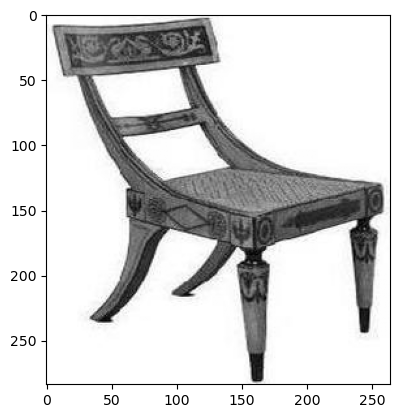

In [25]:
# 이미지 확인하기
import matplotlib.pyplot as plt
plt.imshow(chairData[0].reshape(284, 264), cmap='gray')
plt.show()